# Классификация уведомлений входящей корпоративной почты

Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import spacy
import numpy as np
import evaluate
import fasttext
import os, random

from datasets import Dataset
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, roc_auc_score, 
    ConfusionMatrixDisplay, 
    confusion_matrix, 
    classification_report, 
    f1_score, precision_recall_fscore_support, 
    recall_score, 
    precision_score
    )

from catboost import CatBoostClassifier

from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

'NoneType' object has no attribute 'cadam32bit_grad_fp32'


/Users/michaelboksha/miniconda3/lib/python3.11/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


In [2]:
SEED = 42

# Предросмотр датафрейма 

Предварительно посмотрим на датафрейм, в котором содержатся данные из моей корпоративной почты за 4 года бакалавриата. Разметка уведомлений (столбец is_important) была осуществлена с помощью API OpenAI

In [3]:
df = pd.read_csv("df.csv")

In [4]:
df.head()

,uid,from,to,date,subject,text_plain,text_html,headers,is_important
0,28,Центр поддержки студенческих инициатив НИУ ВШЭ...,sgshengeliya@edu.hse.ru,2022-09-22 10:44:27+00:00,Межкампусный съезд вожатых НИУ ВШЭ «Здесь были»,Приглашаем студентов НИУ ВШЭ принять участие в...,"<!DOCTYPE html><html xmlns:v=""urn:schemas-micr...",{'Received': 'by smtp368.emlone.com id h5gu9g2...,0.0
1,29,Разбаева Екатерина Владимировна (отправлено че...,Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>,2022-09-22 15:01:34+03:00,5427461778_2_82974666: Homework for tomorrow,5427461778_2_82974666 -> Форумы -> Объявления ...,"<div class=""navbar"">\n <a target=""_blank"" h...",{'Received': 'from lms-cron (192.168.202.92) b...,1.0
2,30,Разбаева Екатерина Владимировна (отправлено че...,Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>,2022-09-22 15:01:34+03:00,5427461778_2_82974666: link to the ppt,5427461778_2_82974666 -> Форумы -> Объявления ...,"<div class=""navbar"">\n <a target=""_blank"" h...",{'Received': 'from lms-cron (192.168.202.92) b...,0.0
3,31,Разбаева Екатерина Владимировна (отправлено че...,Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>,2022-09-23 11:11:21+03:00,"5427461778_2_82974666: Для студентов, пропусти...",5427461778_2_82974666 -> Форумы -> Объявления ...,"<div class=""navbar"">\n <a target=""_blank"" h...",{'Received': 'from lms-cron (192.168.202.92) b...,1.0
4,32,Разбаева Екатерина Владимировна (отправлено че...,Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>,2022-09-23 11:18:21+03:00,5427461778_2_82974666: Links to the marksheets,5427461778_2_82974666 -> Форумы -> Объявления ...,"<div class=""navbar"">\n <a target=""_blank"" h...",{'Received': 'from lms-cron (192.168.202.92) b...,1.0


In [5]:
df.tail()

,uid,from,to,date,subject,text_plain,text_html,headers,is_important
3795,1853,Экстра.ВШЭ <extra@hse.ru>,miboksha@edu.hse.ru,2026-01-21 09:21:52+00:00,"Мама, я бегу с ректором!","Мама, я бегу с ректором в субботу!\n\nМама, я ...","<!DOCTYPE html><html xmlns:v=""urn:schemas-micr...",{'Received': 'by smtp1.unisender.hse.ru id he2...,0.0
3796,1854,Сластников Сергей Александрович <sslastnikov@h...,"""miboksha@edu.hse.ru"" <miboksha@edu.hse.ru>",2026-01-21 11:36:45+00:00,Re: [DKIM sender authentication violation] Re[...,"Лучше делать параллельно, иначе потом (постфак...","<html>\r\n<head>\r\n<meta http-equiv=""Content-...",{'Received': 'from mail11.staff.corp.local ([1...,1.0
3797,1855,Гришунина Юлия Борисовна (отправлено через edu...,Бокша Михаил Ильич<miboksha@edu.hse.ru>,2026-01-21 20:08:59+03:00,Новое содержимое курса Прикладные стохастическ...,Задание Домашнее задание №2 [1] является\r\nно...,"<p>Задание <a href=""https://edu.hse.ru/mod/ass...",{'Received': 'from slms2-cron (192.168.202.143...,1.0
3798,1856,Не нужно отвечать на это сообщение (отправлено...,Бокша Михаил Ильич<miboksha@edu.hse.ru>,2026-01-24 01:26:37+03:00,"У вас есть задания, которые нужно сдать через ...","Здравствуйте, Михаил Ильич,\r\n\r\nСледующие з...","<p>Здравствуйте, Михаил Ильич,</p>\n<p>Следующ...",{'Received': 'from slms2-cron (192.168.202.143...,1.0
3799,1857,Яндекс ID <noreply@id.yandex.ru>,miboksha@edu.hse.ru,2026-01-24 13:02:25,Вы создали пароль для приложения в аккаунте mi...,NaN,"<!doctype html>\n<html lang=""ru"" xmlns=""http:/...","{'Received': 'by qavm-f636cfe0.qemu (Postfix, ...",0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   uid           3800 non-null   int64  
 1   from          3800 non-null   object 
 2   to            3800 non-null   object 
 3   date          3800 non-null   object 
 4   subject       3788 non-null   object 
 5   text_plain    3241 non-null   object 
 6   text_html     3445 non-null   object 
 7   headers       3800 non-null   object 
 8   is_important  3800 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 267.3+ KB


([<matplotlib.axis.XTick at 0x3ac56b710>,
 [Text(0, 0, 'Не важно (0)'), Text(1, 0, 'Важно (1)')])

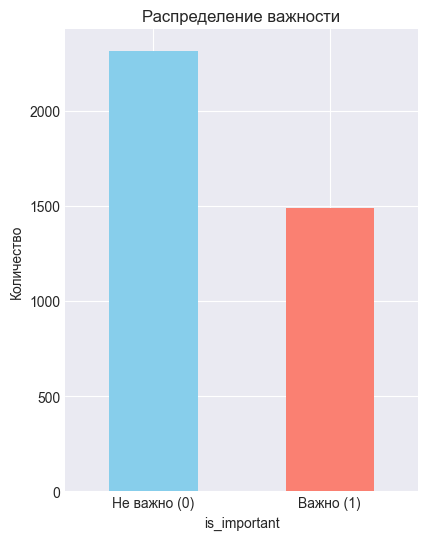

In [7]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
df['is_important'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение важности')
plt.xlabel('is_important')
plt.ylabel('Количество')
plt.xticks([0, 1], ['Не важно (0)', 'Важно (1)'], rotation=0)

In [8]:
pd.set_option('display.max_colwidth', None)  

In [9]:
def clean_text(x: str) -> str:
    if not isinstance(x, str):
        return ""
    x = re.sub(r"\s+", " ", x)
    return x.strip()

def build_text(row):
    subj = clean_text(row.get("subject", ""))
    body = row.get("text_plain", "")
    if not isinstance(body, str) or not body.strip():
        body = row.get("text_html", "")
    body = clean_text(body)
    return f"SUBJECT: {subj}\nBODY: {body}".strip()

df["text"] = df.apply(build_text, axis=1)

df = df[df["text"].str.len() > 0].copy()

df[["uid", "is_important", "subject", "text"]].head()

,uid,is_important,subject,text
0,28,0.0,Межкампусный съезд вожатых НИУ ВШЭ «Здесь были»,"SUBJECT: Межкампусный съезд вожатых НИУ ВШЭ «Здесь были»\nBODY: Приглашаем студентов НИУ ВШЭ принять участие в межкампусном выезде вожатых «Здесь были». «Здесь были» (https://vk.com/hseforkidscampus) — это новый образовательный проект, нацеленный на создание вожатского комьюнити внутри кампусов НИУ ВШЭ. 7 –– 9 октября Уже действующие вожатые НИУ ВШЭ из Москвы, Санкт-Петербурга, Нижнего Новгорода и Перми бесплатно смогут: пройти серию образовательных мастер-классов по организации педагогического отряда; обменяться опытом работы с детскими коллективами и поделиться лучшими педагогическими практиками; сформировать штаб педотрядов в своих регионах, который будет организовывать мероприятия для детей как в стенах университета, так и за его пределами По итогам выезда команды из разных кампусов НИУ ВШЭ будут реализовывать собственные мероприятия для детей у себя в регионах. Зарегистрироваться на проект можно до 25 сентября. Скорее заполняй форму! Хочу участвовать С уважением, Центр поддержки студенческих инициатив НИУ ВШЭ Чтобы отписаться от этой рассылки, перейдите по ссылке (https://uni.unisender.hse.ru/ru/unsubscribe?hash=6k6j548jf6prp3nkbmz1k166b4yt7ieoyxu5jpawurtf4jpfgzo3wnqx7cky3s54rkzaofqzf3nk16#no_tracking)"
1,29,1.0,5427461778_2_82974666: Homework for tomorrow,"SUBJECT: 5427461778_2_82974666: Homework for tomorrow\nBODY: 5427461778_2_82974666 -> Форумы -> Объявления -> Homework for tomorrow https://edu.hse.ru/mod/forum/discuss.php?d=11021#p14989 Homework for tomorrow от Разбаева Екатерина Владимировна - Четверг, 22 сентября 2022, 14:31 --------------------------------------------------------------------- Greetings, dear students! Here is your homework: 1) read the reading passage 1.2 Reading from topic Education in the LMS till the end 2) draw a flow chart with steps of the learning process --------------------------------------------------------------------- Изменить Ваши настройки дайджеста форума: https://edu.hse.ru/mod/forum/index.php?id=121712"
2,30,0.0,5427461778_2_82974666: link to the ppt,"SUBJECT: 5427461778_2_82974666: link to the ppt\nBODY: 5427461778_2_82974666 -> Форумы -> Объявления -> link to the ppt https://edu.hse.ru/mod/forum/discuss.php?d=11019#p14987 link to the ppt от Разбаева Екатерина Владимировна - Четверг, 22 сентября 2022, 14:29 --------------------------------------------------------------------- Dear students, Here is a link to our presentation for your reference: https://docs.google.com/presentation/d/1jE8WxmHewzs7tgt2KB5-Trcufq6EZjii_cSqAhdCLBY/edit?usp=sharing Here is a link to classroom rules: https://docs.google.com/document/d/1R-8Q1Qff-385CbmgH71sxb6AyT5lEnlM/edit Keep in mind that your active participation in the classroom work lets you get points for Independent work. --------------------------------------------------------------------- Изменить Ваши настройки дайджеста форума: https://edu.hse.ru/mod/forum/index.php?id=121712"
3,31,1.0,"5427461778_2_82974666: Для студентов, пропустивших первое занятия из-за позднего подключения к курсу","SUBJECT: 5427461778_2_82974666: Для студентов, пропустивших первое занятия из-за позднего подключения к курсу\nBODY: 5427461778_2_82974666 -> Форумы -> Объявления -> Для студентов, пропустивших первое занятия из-за позднего подключения к курсу https://edu.hse.ru/mod/forum/discuss.php?d=11074#p15083 Для студентов, пропустивших первое занятия из-за позднего подключения к курсу от Разбаева Екатерина Владимировна - Пятница, 23 сентября 2022, 10:41 --------------------------------------------------------------------- Уважаемые студенты, добрый день! Я уточнила по поводу того, что делать тем, кто не смог присутствовать на 1 занятии из-за накладок в расписании или из-за того, что вас поздно подключили к курсу. Так как этот случай можно расценить как форс-мажор, у вас есть возможность получить баллы за пропущенные занятия по критерию independent work (максимально 1 балл: 0,5 за

# Предобработка текстовых данных перед применением классических методов

В первую очередь осуществим очистку текста 

In [10]:
def clear_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text)
    return text

df['text_clear'] = df['text'].apply(clear_text)

Теперь можно лемматизировать текст как на русском, так и на английском языках

In [11]:
nlp_ru = spacy.load('ru_core_news_sm', disable=['parser', 'ner'])

def lemmatize(text):
    doc = nlp_ru(text)
    return ' '.join([token.lemma_ for token in doc])

df['lemma'] = df['text_clear'].apply(lemmatize)

In [12]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lemmatize_eng(text):
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

df['lemma'] = df['lemma'].apply(lemmatize_eng)

Предварительно взглянем на данные, чтобы убедиться в корректности своих действий

In [13]:
df.head()

uid  \
0   28   
1   29   
2   30   
3   31   
4   32   

                                                                              from  \
0              Центр поддержки студенческих инициатив НИУ ВШЭ <studsupport@hse.ru>   
1  Разбаева Екатерина Владимировна (отправлено через edu.hse.ru) <smartlms@hse.ru>   
2  Разбаева Екатерина Владимировна (отправлено через edu.hse.ru) <smartlms@hse.ru>   
3  Разбаева Екатерина Владимировна (отправлено через edu.hse.ru) <smartlms@hse.ru>   
4  Разбаева Екатерина Владимировна (отправлено через edu.hse.ru) <smartlms@hse.ru>   

                                                to                       date  \
0                          sgshengeliya@edu.hse.ru  2022-09-22 10:44:27+00:00   
1  Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>  2022-09-22 15:01:34+03:00   
2  Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>  2022-09-22 15:01:34+03:00   
3  Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>  2022-09-23 11:11:21+03:00   
4  Шенгелия Софья Гочевна<sgshengeliya@edu.hse.ru>  2022-09-23 11:18:21+03:00   

                                                                                                subject  \
0                                                       Межкампусный съезд вожатых НИУ ВШЭ «Здесь были»   
1                                                          5427461778_2_82974666: Homework for tomorrow   
2                                                                5427461778_2_82974666: link to the ppt   
3  5427461778_2_82974666: Для студентов, пропустивших первое занятия из-за позднего подключения к курсу   
4                                                        5427461778_2_82974666: Links to the marksheets   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            text_plain  \
0                                                                                                                                                                                                                                                                                                                                                                                        Приглашаем студентов НИУ ВШЭ принять участие в межкампусном выезде вожатых «Здесь были».\n\n«Здесь были» (https://vk.com/hseforkidscampus) — это новый образовательный проект, нацеленный на создание вожатского комьюнити внутри кампусов НИУ ВШЭ.\n\n7 –– 9 октября\n\nУже действующие вожатые НИУ ВШЭ из Москвы, Санкт-Петербурга, Нижнего Новгор

In [14]:
df.to_csv("df_prepared.csv", index=False)
print("Сохранено: df_prepared.csv")

Сохранено: df_prepared.csv


In [15]:
def choose_threshold(y_true, p, method="max_f1", target_recall=0.92):
    thresholds = np.linspace(0.05, 0.95, 181)
    best = {"th": 0.5, "f1": -1, "prec": None, "rec": None}

    if method == "max_f1":
        for th in thresholds:
            pred = (p >= th).astype(int)
            f1 = f1_score(y_true, pred, zero_division=0)
            if f1 > best["f1"]:
                best.update(th=float(th),
                            f1=float(f1),
                            prec=float(precision_score(y_true, pred, zero_division=0)),
                            rec=float(recall_score(y_true, pred, zero_division=0)))
        return best

    if method == "recall_constraint":
        candidates = []
        for th in thresholds:
            pred = (p >= th).astype(int)
            rec = recall_score(y_true, pred, zero_division=0)
            if rec >= target_recall:
                prec = precision_score(y_true, pred, zero_division=0)
                f1 = f1_score(y_true, pred, zero_division=0)
                candidates.append((prec, f1, th, rec))
        if not candidates:
            return choose_threshold(y_true, p, method="max_f1")
        prec, f1, th, rec = sorted(candidates, reverse=True)[0]
        return {"th": float(th), "f1": float(f1), "prec": float(prec), "rec": float(rec)}

    raise ValueError("unknown method")

# TF-IDF + LogisticRegression

Классы несбалансированы, учтем это

In [16]:
X_text = df["lemma"].values  
y = df["is_important"].astype(int).values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.15, random_state=SEED, stratify=y
)

base_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_proba = np.zeros(len(X_train_text), dtype=np.float32)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_text, y_train), 1):
    X_tr, X_va = X_train_text[tr_idx], X_train_text[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    m = base_model
    m.fit(X_tr, y_tr)
    p_va = m.predict_proba(X_va)[:, 1]
    oof_proba[va_idx] = p_va

calibrator = LogisticRegression(solver="lbfgs", random_state=SEED)
calibrator.fit(oof_proba.reshape(-1, 1), y_train)
oof_proba_cal = calibrator.predict_proba(oof_proba.reshape(-1, 1))[:, 1]

best = choose_threshold(y_train, oof_proba_cal, method="max_f1")

print("TFIDF OOF AUC:", roc_auc_score(y_train, oof_proba_cal))
print("TFIDF chosen threshold:", best)

final_model = base_model
final_model.fit(X_train_text, y_train)

p_test = final_model.predict_proba(X_test_text)[:, 1]
p_test_cal = calibrator.predict_proba(p_test.reshape(-1, 1))[:, 1]
pred_test = (p_test_cal >= best["th"]).astype(int)

print("\nTFIDF TEST AUC:", roc_auc_score(y_test, p_test_cal))
print("TFIDF TEST Precision:", precision_score(y_test, pred_test, zero_division=0))
print("TFIDF TEST Recall:", recall_score(y_test, pred_test, zero_division=0))
print("TFIDF TEST F1:", f1_score(y_test, pred_test, zero_division=0))
print("TFIDF Final threshold:", best["th"])


TFIDF OOF AUC: 0.9754991505873496
TFIDF chosen threshold: {'th': 0.245, 'f1': 0.9172932330827067, 'prec': 0.8751793400286944, 'rec': 0.9636650868878357}

TFIDF TEST AUC: 0.9779403212674946
TFIDF TEST Precision: 0.8709677419354839
TFIDF TEST Recall: 0.968609865470852
TFIDF TEST F1: 0.9171974522292994
TFIDF Final threshold: 0.245


# Оценка метрик

In [17]:
def plot_roc_and_cm_from_scores(y_true, proba, title="", threshold=0.5):
    auc = roc_auc_score(y_true, proba)
    fpr, tpr, _ = roc_curve(y_true, proba)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC curve — {title}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    plt.figure(figsize=(5, 4))
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix (th={threshold:.3f}) — {title}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    return auc, cm

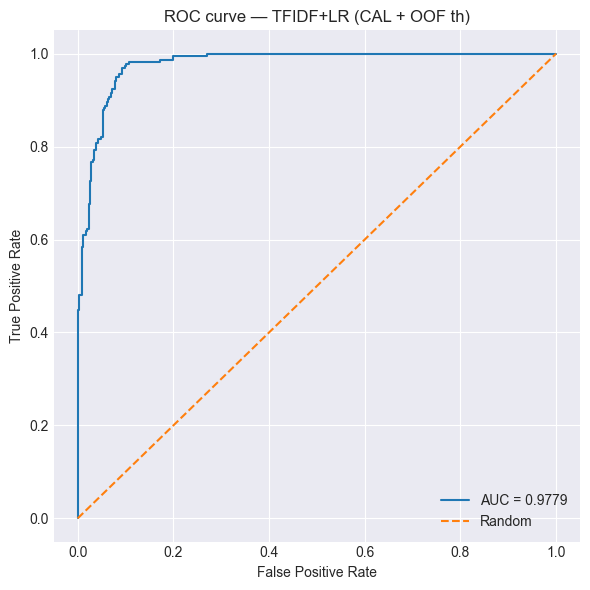

<Figure size 500x400 with 0 Axes>

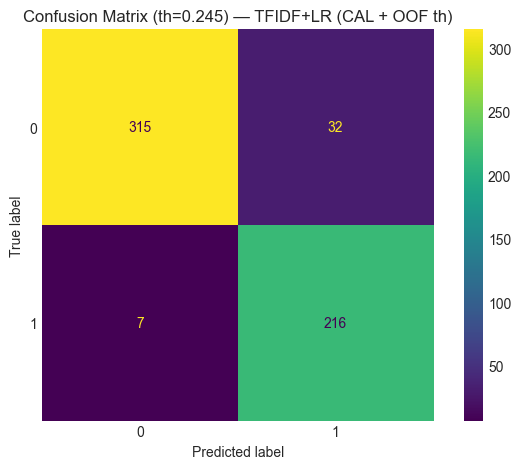

(np.float64(0.9779403212674946),
 array([[315,  32],
        [  7, 216]]))

In [18]:
p_test_raw = final_model.predict_proba(X_test_text)[:, 1]

p_test_cal = calibrator.predict_proba(p_test_raw.reshape(-1, 1))[:, 1]

plot_roc_and_cm_from_scores(
    y_test, p_test_cal,
    title="TFIDF+LR (CAL + OOF th)",
    threshold=best["th"]
)

# RuBERT-tiny2

In [19]:
def softmax_np(logits: np.ndarray) -> np.ndarray:
    ex = np.exp(logits - logits.max(axis=1, keepdims=True))
    return ex / ex.sum(axis=1, keepdims=True)

# Дообучим нашу модель на текстах (не лемматизированных, но очищенных от "мусора")

In [20]:
X_text = df["text_clear"].values
y = df["is_important"].astype(int).values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.15, random_state=SEED, stratify=y
)

print("train:", len(X_train_text), "test:", len(X_test_text), "pos_rate_train:", y_train.mean())

MODEL_NAME = "cointegrated/rubert-tiny2"
MAX_LEN = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

def make_ds(texts, labels=None):
    if labels is None:
        labels = [0] * len(texts)
    ds = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    ds = ds.map(tokenize_batch, batched=True, remove_columns=["text"])
    return ds

def train_fold_and_predict_proba(X_tr, y_tr, X_va, fold_id: int):
    train_ds = make_ds(X_tr, y_tr)
    val_ds   = make_ds(X_va, None)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    args = TrainingArguments(
        output_dir=f"bert_cv_out/fold_{fold_id}",
        eval_strategy="no",
        save_strategy="no",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_steps=200,
        fp16=False, 
        bf16=False,
        dataloader_num_workers=0, 
        seed=SEED,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        data_collator=collator,
        tokenizer=tokenizer,
    )

    trainer.train()

    pred = trainer.predict(val_ds)
    logits = pred.predictions
    proba = softmax_np(logits)[:, 1]
    return proba

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_proba = np.zeros(len(X_train_text), dtype=np.float32)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train_text, y_train), 1):
    X_tr, X_va = X_train_text[tr_idx], X_train_text[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    p_va = train_fold_and_predict_proba(X_tr, y_tr, X_va, fold_id=fold)
    oof_proba[va_idx] = p_va

print("BERT OOF (raw) AUC:", roc_auc_score(y_train, oof_proba))

calibrator = LogisticRegression(solver="lbfgs", random_state=SEED)
calibrator.fit(oof_proba.reshape(-1, 1), y_train)
oof_proba_cal = calibrator.predict_proba(oof_proba.reshape(-1, 1))[:, 1]

print("BERT OOF (cal) AUC:", roc_auc_score(y_train, oof_proba_cal))

best = choose_threshold(y_train, oof_proba_cal, method="max_f1")

print("BERT chosen threshold:", best)

train_full = make_ds(X_train_text, y_train)
test_ds    = make_ds(X_test_text, y_test)

final_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
final_args = TrainingArguments(
    output_dir="bert_final_out",
    eval_strategy="no",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=200,
    fp16=False,
    bf16=False,
    dataloader_num_workers=0,
    seed=SEED,
    report_to=[],
)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_full,
    data_collator=collator,
    tokenizer=tokenizer,
)

final_trainer.train()

pred = final_trainer.predict(test_ds)
p_test_raw = softmax_np(pred.predictions)[:, 1]
p_test_cal = calibrator.predict_proba(p_test_raw.reshape(-1, 1))[:, 1]

y_pred = (p_test_cal >= best["th"]).astype(int)

print("\nBERT TEST AUC:", roc_auc_score(y_test, p_test_cal))
print("BERT TEST Precision:", precision_score(y_test, y_pred, zero_division=0))
print("BERT TEST Recall:", recall_score(y_test, y_pred, zero_division=0))
print("BERT TEST F1:", f1_score(y_test, y_pred, zero_division=0))
print("BERT Final threshold:", best["th"])


train: 3230 test: 570 pos_rate_train: 0.39195046439628484


Map:   0%|          | 0/2584 [00:00<?, ? examples/s]

Map:   0%|          | 0/646 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/vw/_cq5r1fj74l3xpzg4yc19gw80000gn/T/ipykernel_52253/3046313251.py:48: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/michaelboksha/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
200,0.455000
400,0.255700


...

Map:   0%|          | 0/3230 [00:00<?, ? examples/s]

Map:   0%|          | 0/570 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/vw/_cq5r1fj74l3xpzg4yc19gw80000gn/T/ipykernel_52253/3046313251.py:107: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(
/Users/michaelboksha/miniconda3/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
200,0.473500
400,0.252000
600,0.208500



BERT TEST AUC: 0.9605975627091922
BERT TEST Precision: 0.8619246861924686
BERT TEST Recall: 0.9237668161434978
BERT TEST F1: 0.8917748917748918
BERT Final threshold: 0.37499999999999994


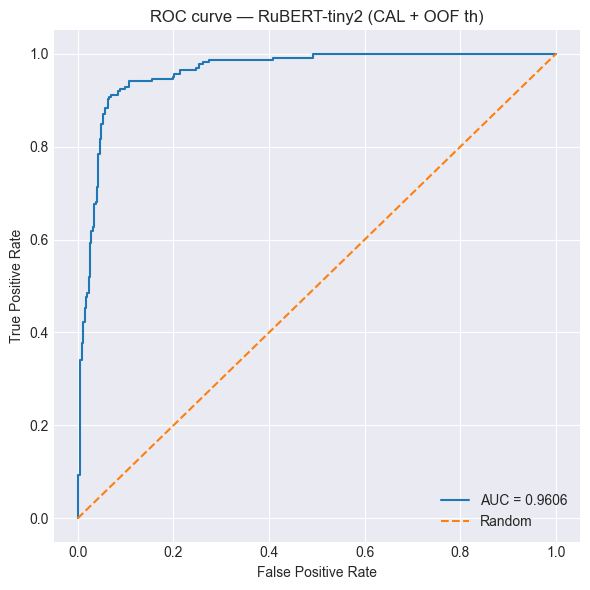

<Figure size 500x400 with 0 Axes>

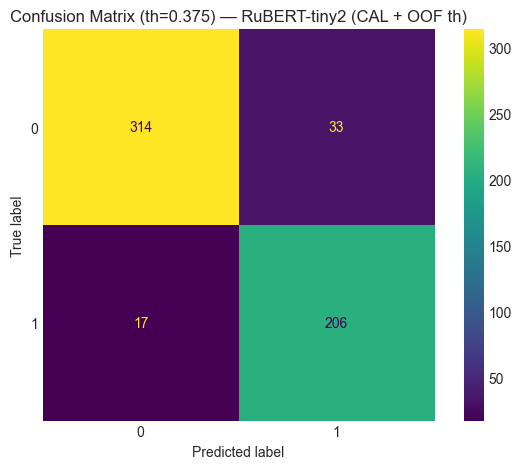

(np.float64(0.9605975627091922),
 array([[314,  33],
        [ 17, 206]]))

In [21]:
plot_roc_and_cm_from_scores(
    y_test, p_test_cal,
    title="RuBERT-tiny2 (CAL + OOF th)",
    threshold=best["th"]
)

In [22]:
final_trainer.save_model("bert_importance_classifier")
tokenizer.save_pretrained("bert_importance_classifier")
print("Saved: bert_importance_classifier/")

Saved: bert_importance_classifier/


метрики вышли неплохие, но классические методы показали лучшие результаты. Оценим качество более крупной модели

# FastText + Catboost

Попробуем самый оптимальный подход, объединяющий в себе как нейросетевой метод, так и классический подход 

In [23]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print("train:", len(X_train_text), "test:", len(X_test_text), "pos_rate_train:", y_train.mean())

train_corpus_path = Path("ft_corpus_train.txt")
with train_corpus_path.open("w", encoding="utf-8") as f:
    for t in X_train_text:
        f.write(str(t).replace("\n", " ") + "\n")

ft = fasttext.train_unsupervised(
    input=str(train_corpus_path),
    model="skipgram",
    dim=100,
    epoch=15,
    minn=2,
    maxn=5,
    ws=5,
    lr=0.05,
    thread=1, 
)

ft.save_model("ft_unsup.bin")

def texts_to_matrix(texts, ft_model):
    return np.vstack([ft_model.get_sentence_vector(str(t)) for t in texts]).astype(np.float32)

Xtr = texts_to_matrix(X_train_text, ft)
Xte = texts_to_matrix(X_test_text, ft)

print("Xtr:", Xtr.shape, "Xte:", Xte.shape)

def choose_threshold(y_true, p, method="max_f1", target_recall=0.92):
    thresholds = np.linspace(0.05, 0.95, 181)

    best = {"th": 0.5, "f1": -1, "prec": None, "rec": None}

    if method == "max_f1":
        for th in thresholds:
            pred = (p >= th).astype(int)
            f1 = f1_score(y_true, pred)
            if f1 > best["f1"]:
                best.update(th=float(th),
                            f1=float(f1),
                            prec=float(precision_score(y_true, pred, zero_division=0)),
                            rec=float(recall_score(y_true, pred, zero_division=0)))
        return best

    if method == "recall_constraint":
        candidates = []
        for th in thresholds:
            pred = (p >= th).astype(int)
            rec = recall_score(y_true, pred, zero_division=0)
            if rec >= target_recall:
                prec = precision_score(y_true, pred, zero_division=0)
                f1 = f1_score(y_true, pred, zero_division=0)
                candidates.append((prec, f1, th, rec))
        if not candidates:
            return choose_threshold(y_true, p, method="max_f1")

        prec, f1, th, rec = sorted(candidates, reverse=True)[0]
        return {"th": float(th), "f1": float(f1), "prec": float(prec), "rec": float(rec)}

    raise ValueError("unknown method")


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_proba = np.zeros(len(Xtr), dtype=np.float32)
fold_thresholds = []

pos = float(y_train.mean())
class_weights = [1.0, (1.0 - pos) / max(pos, 1e-6)]

cat_params = dict(
    iterations=3000,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=SEED,
    verbose=False,
    class_weights=class_weights,
    thread_count=1,
    allow_writing_files=False
)

for fold, (tr_idx, va_idx) in enumerate(skf.split(Xtr, y_train), 1):
    X_tr, X_va = Xtr[tr_idx], Xtr[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    clf = CatBoostClassifier(**cat_params)
    clf.fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True, verbose=False)

    p_va = clf.predict_proba(X_va)[:, 1]
    oof_proba[va_idx] = p_va

    best_fold = choose_threshold(y_va, p_va, method="max_f1")
    fold_thresholds.append(best_fold["th"])

print("Fold thresholds:", np.round(fold_thresholds, 3))
print("Median fold th:", float(np.median(fold_thresholds)))

calibrator = LogisticRegression(solver="lbfgs", random_state=SEED)
calibrator.fit(oof_proba.reshape(-1, 1), y_train)

oof_proba_cal = calibrator.predict_proba(oof_proba.reshape(-1, 1))[:, 1]

best = choose_threshold(y_train, oof_proba_cal, method="max_f1")

print("Chosen OOF threshold:", best)

print("OOF AUC:", roc_auc_score(y_train, oof_proba_cal))

final_clf = CatBoostClassifier(**cat_params)
final_clf.fit(Xtr, y_train, verbose=False)

p_test = final_clf.predict_proba(Xte)[:, 1]
p_test_cal = calibrator.predict_proba(p_test.reshape(-1, 1))[:, 1]

pred_test = (p_test_cal >= best["th"]).astype(int)

print("\nTEST AUC:", roc_auc_score(y_test, p_test_cal))
print("TEST Precision:", precision_score(y_test, pred_test, zero_division=0))
print("TEST Recall:", recall_score(y_test, pred_test, zero_division=0))
print("TEST F1:", f1_score(y_test, pred_test, zero_division=0))
print("Final threshold:", best["th"])

train: 3230 test: 570 pos_rate_train: 0.39195046439628484


Read 3M words
Number of words:  21849
Number of labels: 0
Progress: 100.0% words/sec/thread:  147254 lr:  0.000000 avg.loss:  0.584478 ETA:   0h 0m 0s


Xtr: (3230, 100) Xte: (570, 100)
Fold thresholds: [0.555 0.435 0.285 0.36  0.36 ]
Median fold th: 0.35999999999999993
Chosen OOF threshold: {'th': 0.31499999999999995, 'f1': 0.934984520123839, 'prec': 0.9165402124430956, 'rec': 0.9541864139020537}
OOF AUC: 0.9805469622236593

TEST AUC: 0.9865212390638529
TEST Precision: 0.9227467811158798
TEST Recall: 0.9641255605381166
TEST F1: 0.9429824561403509
Final threshold: 0.31499999999999995


In [24]:
test_proba = p_test_cal
test_pred  = (test_proba >= best["th"]).astype(int)

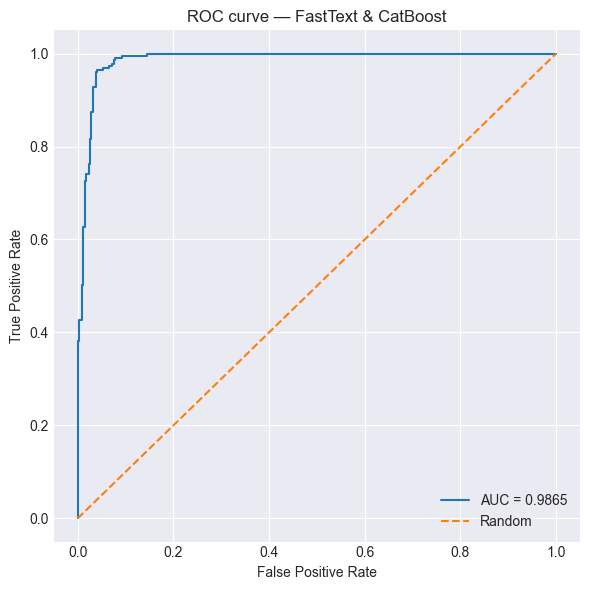

<Figure size 500x400 with 0 Axes>

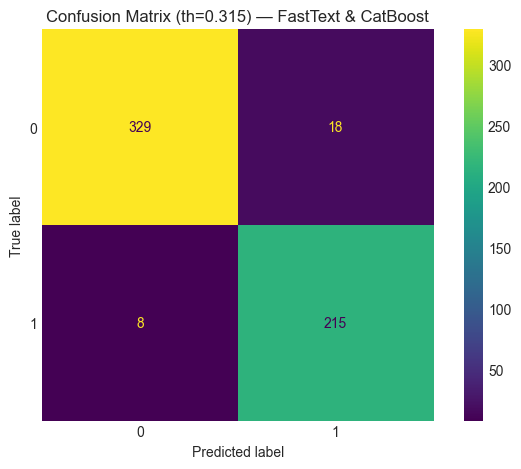

(np.float64(0.9865212390638529),
 array([[329,  18],
        [  8, 215]]))

In [25]:
plot_roc_and_cm_from_scores(
    y_test, p_test_cal,
    title="FastText & CatBoost",
    threshold=best["th"]
)

In [ ]:
test_proba = p_test_cal
test_pred  = (test_proba >= best["th"]).astype(int)

fn_mask = (y_test == 1) & (test_pred == 0)

print("False Negatives:", fn_mask.sum())

y = df["is_important"].astype(int).values
idx = np.arange(len(df))
_, idx_test, _, _ = train_test_split(idx, y, test_size=0.15, random_state=SEED, stratify=y)

fn_idx = idx_test[fn_mask]

fn_df = df.loc[fn_idx, ["text", "text_clear"]].copy()
fn_df["proba_important"] = test_proba[fn_mask]
fn_df = fn_df.sort_values("proba_important", ascending=False)

display(fn_df.head(20))

for i, row in fn_df.head(10).iterrows():
    print(f"\n--- FN | p(important)={row['proba_important']:.4f} | idx={i} ---")
    print(row["text_clear"])


False Negatives: 8


text  \
3279                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    


--- FN | p(important)=0.1758 | idx=3279 ---
subject кис группа 1 итоговая работа 12 декабря 13 00 body div div a href https telemost yandex ru j 32385799006993 rel noopener noreferrer target _blank https telemost yandex ru j 32385799006993 a div div div div 12 декабря 13 00 div div 

--- FN | p(important)=0.0546 | idx=3659 ---
subject я профессионал информация об учете дипломов прошлого сезона и не только body doctype html html head meta content width device width initial scale 1 0 name viewport meta content text html charset utf 8 http equiv content type title я профессионал информационная рассылка title style media only screen and max width 700px table body h1 font size 22px important margin bottom 10px important table body h2 font size 20px important table body p table body ul table body ol table body td table body span table body a font size 16px important table body wrapper table body article padding 10px important table body content padding 0 important table body container paddi

## Сохранение моделей для дальнейшего использования

In [ ]:
import json
from pathlib import Path

base_dir = Path.cwd()
export_dir = base_dir / "artifacts"
export_dir.mkdir(parents=True, exist_ok=True)

assert "ft" in globals(), "Не найдена FastText-модель `ft` (сначала запусти ячейку обучения)."
assert "final_clf" in globals(), "Не найдена бустинг-модель `final_clf` (сначала запусти ячейку обучения)."

fasttext_path = export_dir / "fasttext_unsup.bin"  
catboost_path = export_dir / "catboost_final.cbm"  
meta_path = export_dir / "meta.json"

ft.save_model(str(fasttext_path))
final_clf.save_model(str(catboost_path))

meta = {
    "fasttext_path": str(fasttext_path.resolve()),
    "catboost_path": str(catboost_path.resolve()),
    "cwd": str(base_dir.resolve())
}

if "best" in globals() and isinstance(best, dict) and "th" in best:
    meta["threshold"] = float(best["th"])

if "cat_params" in globals():
    try:
        meta["cat_params"] = cat_params
    except Exception:
        pass

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✅ Models exported")
for p in [fasttext_path, catboost_path, meta_path]:
    print(f"- {p} | exists={p.exists()} | size={p.stat().st_size if p.exists() else 0} bytes")

✅ Models exported
- /Users/michaelboksha/Desktop/ВШЭ/4 курс/ВКР/диплом код/mock-vkr/artifacts/fasttext_unsup.bin | exists=True | size=818068164 bytes
- /Users/michaelboksha/Desktop/ВШЭ/4 курс/ВКР/диплом код/mock-vkr/artifacts/catboost_final.cbm | exists=True | size=3362144 bytes
- /Users/michaelboksha/Desktop/ВШЭ/4 курс/ВКР/диплом код/mock-vkr/artifacts/meta.json | exists=True | size=716 bytes
